## CHECKING THE TF RECORDS ##

In [1]:
import os
folder = 'E:/CGAN/rfe_tfrecords'
for f in sorted(os.listdir(folder)):
    if f.startswith('2018') and f.endswith('.tfrecords'):
        sz = os.path.getsize(os.path.join(folder, f))
        print(f"{f}  {sz/1e6:.1f} MB")


2018_1.0.tfrecords  291.2 MB
2018_1.1.tfrecords  386.7 MB
2018_1.2.tfrecords  270.6 MB
2018_1.3.tfrecords  625.7 MB


# Test that the input data is the correct orientation etc.#

In [2]:
# Test that the input data is the correct orientation etc.

import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
from datetime import datetime, timedelta
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import xarray as xr

import sys
sys.path.insert(1, 'E:/CGAN/SEWAA-forecasts/24h_accumulations/cGAN/dsrnngan')

In [4]:
# cGAN imports
from data_generator import DataGenerator
from data import get_dates, all_fcst_fields, load_fcst_norm
from plots import gridplot
from data import denormalise

Loading forecast normalisations
In load_fcst_norm
fcstnorm_path = E:/CGAN/SEWAA-forecasts/24h_accumulations/cGAN/FCSTNorm2018.pkl


In [5]:
dates = get_dates(2020, 0, 24)
dgc = DataGenerator(dates, all_fcst_fields, batch_size=4, fcst_norm=True, constants=True)

In [6]:
item_no = 47
sample = dgc.__getitem__(item_no)
dates_batch = dgc.dates[item_no*dgc.batch_size:(item_no+1)*dgc.batch_size]

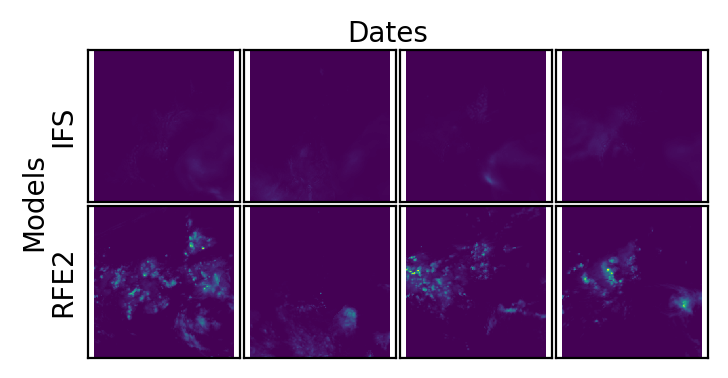

In [7]:
gridplot([denormalise(sample[0]["lo_res_inputs"][..., 0]),
          denormalise(sample[1]["output"][...])],
         model_labels=["IFS", "RFE2"],
         vmin=0.0,
         vmax=5.0)

cGAN truth output


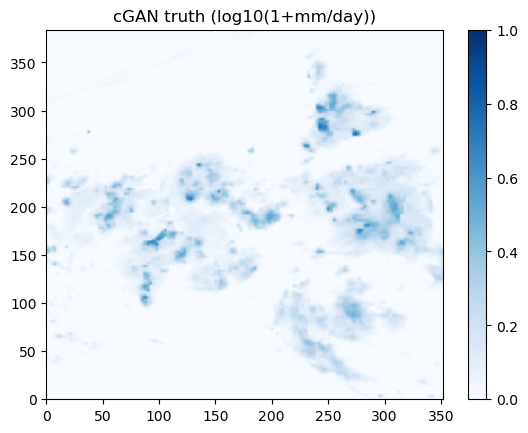

RFE2 direct from file
Loading: E:/CGAN/RFE/2020/20200504.nc


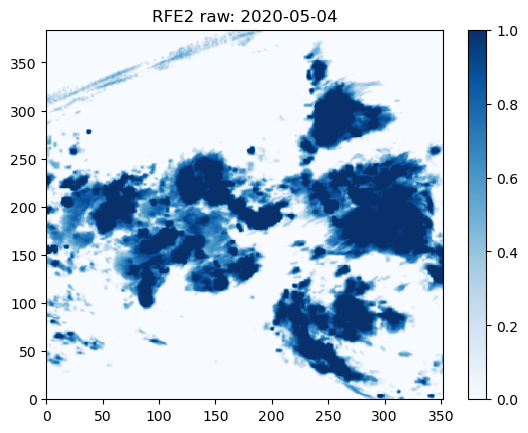

In [7]:
##################
# RFE2 rainfall  #
##################

print("cGAN truth output")
plt.pcolormesh(np.squeeze(sample[1]["output"][0,:,:]), vmin=0, vmax=1, cmap="Blues")
plt.colorbar()
plt.title("cGAN truth (log10(1+mm/day))")
plt.show()

print("RFE2 direct from file")
from datetime import datetime, timedelta
fcst_date = datetime.strptime(dates_batch[0], "%Y%m%d")
truth_date = fcst_date + timedelta(days=1)
rfe_path = f"E:/CGAN/RFE/{truth_date.year}/{truth_date.strftime("%Y%m%d")}.nc"
print(f"Loading: {rfe_path}")
ds_rfe = xr.open_dataset(rfe_path)
rain = ds_rfe["precipitation"].values.squeeze()
rfe_lats = ds_rfe["lat"].values
rfe_lons = ds_rfe["lon"].values
ds_rfe.close()
if rfe_lats[0] > rfe_lats[-1]:
    rain = rain[::-1, :]
    rfe_lats = rfe_lats[::-1]
rain = np.where(np.isnan(rain) | (rain < 0), 0.0, rain)
rain_log = np.log10(1 + rain)
plt.pcolormesh(rain_log, vmin=0, vmax=1, cmap="Blues")
plt.colorbar()
plt.title(f"RFE2 raw: {truth_date.strftime("%Y-%m-%d")}")
plt.show()


cGAN Orography


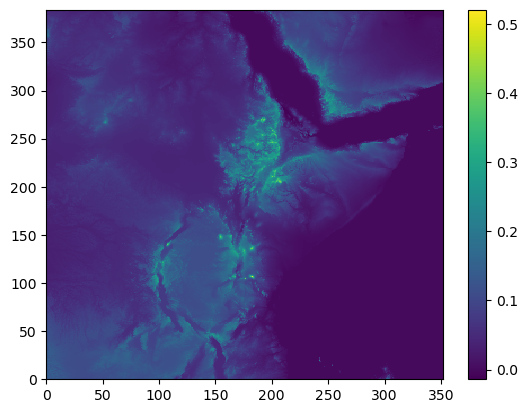

Orography from local constants


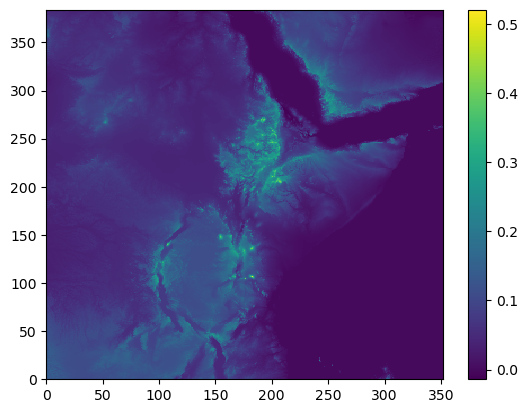

Max difference: 0.0


In [8]:
#############
# Orography #
#############

print("cGAN Orography")
plt.pcolormesh(np.squeeze(sample[0]["hi_res_inputs"][0,:,:,0]))
plt.colorbar()
plt.show()

print("Orography from local constants")
ds_elev = xr.open_dataset("E:/CGAN/SEWAA-forecasts/cGAN_data/elev.nc")
lat = ds_elev["lat"].values
lon = ds_elev["lon"].values
plot_field = ds_elev["elevation"].values / 10000
ds_elev.close()
plt.pcolormesh(plot_field)
plt.colorbar()
plt.show()
print(f"Max difference: {np.max(np.abs(plot_field - np.squeeze(sample[0]["hi_res_inputs"][0,:,:,0])))}")


cGAN land-sea mask


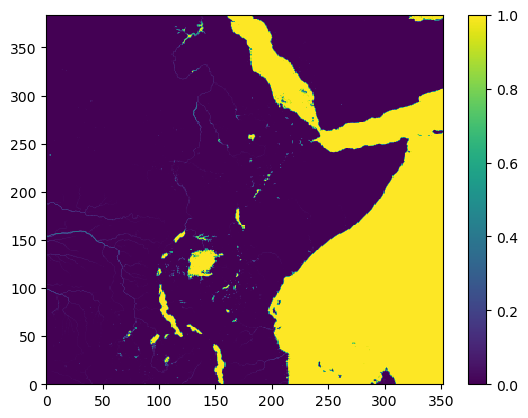

LSM from local constants


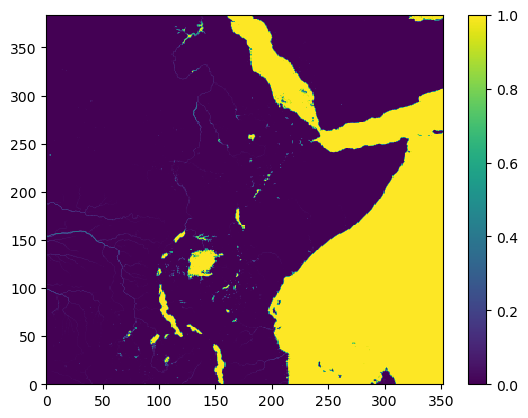

Max difference: 0.0


In [9]:
#################
# Land-Sea mask #
#################

print("cGAN land-sea mask")
plt.pcolormesh(np.squeeze(sample[0]["hi_res_inputs"][0,:,:,1]))
plt.colorbar()
plt.show()

print("LSM from local constants")
ds_lsm = xr.open_dataset("E:/CGAN/SEWAA-forecasts/cGAN_data/lsm.nc")
lat = ds_lsm["lat"].values
lon = ds_lsm["lon"].values
plot_field = ds_lsm["lsm"].values
ds_lsm.close()
plt.pcolormesh(plot_field)
plt.colorbar()
plt.show()
print(f"Max difference: {np.max(np.abs(plot_field - np.squeeze(sample[0]["hi_res_inputs"][0,:,:,1])))}")


In [13]:
fcst_norm = load_fcst_norm(2018)

In load_fcst_norm
fcstnorm_path = E:/CGAN/SEWAA-forecasts/24h_accumulations/cGAN/FCSTNorm2018.pkl


tp


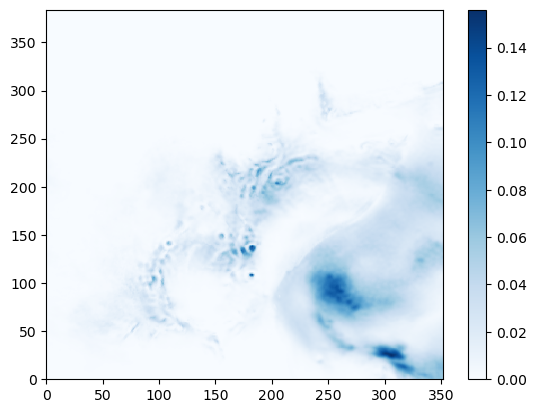

Date in cGAN  : 2020-05-03 00:00:00
Date in netCDF: 2020-05-03 00:00:00
Dates are the same


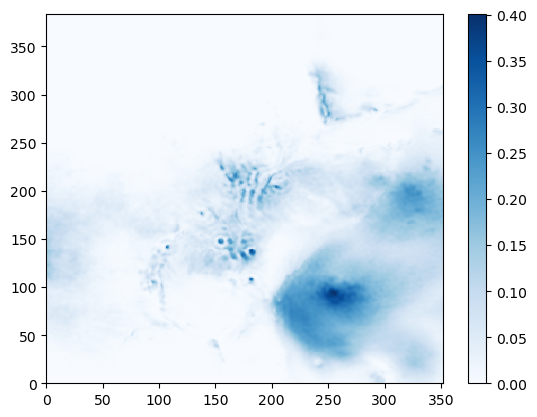

Max difference = 0.27201755790645116


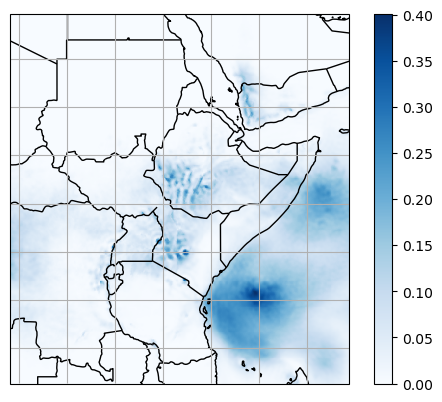

t2m


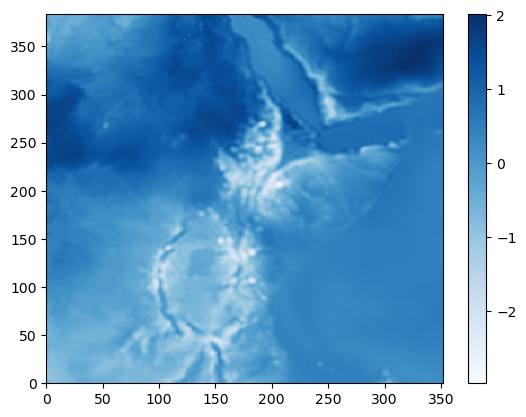

Date in cGAN  : 2020-05-03 00:00:00
Date in netCDF: 2020-05-03 00:00:00
Dates are the same


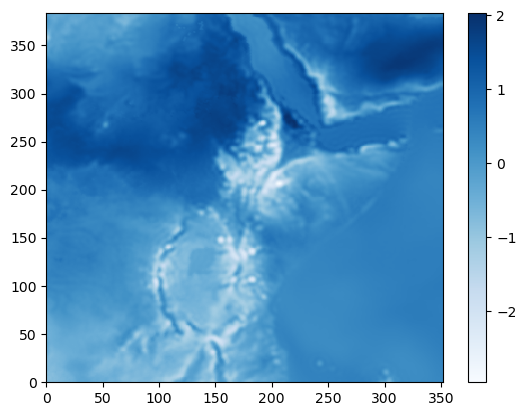

Max difference = 0.6960053279543112


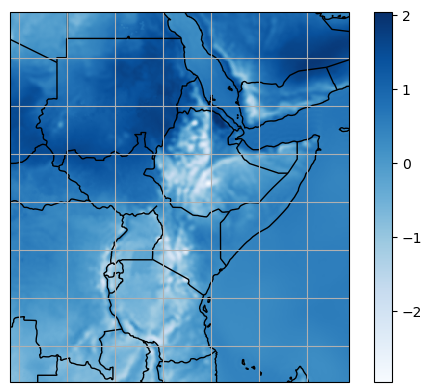

tcwv


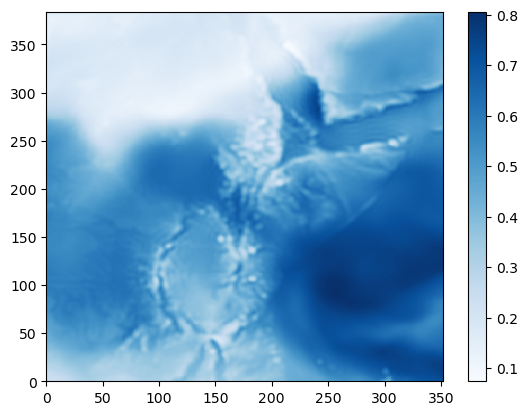

Date in cGAN  : 2020-05-03 00:00:00
Date in netCDF: 2020-05-03 00:00:00
Dates are the same


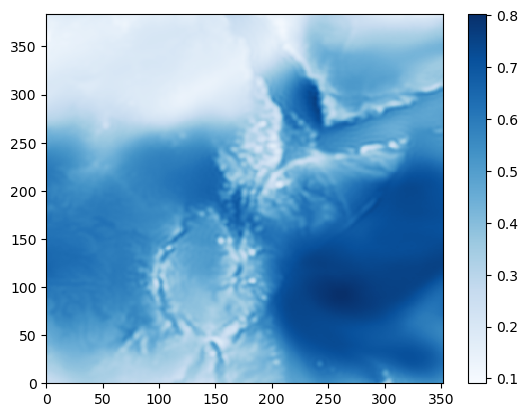

Max difference = 0.22810679098915038


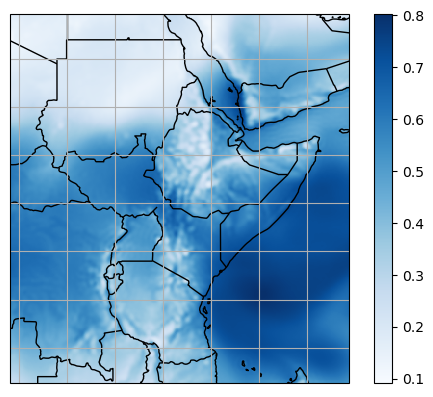

sp


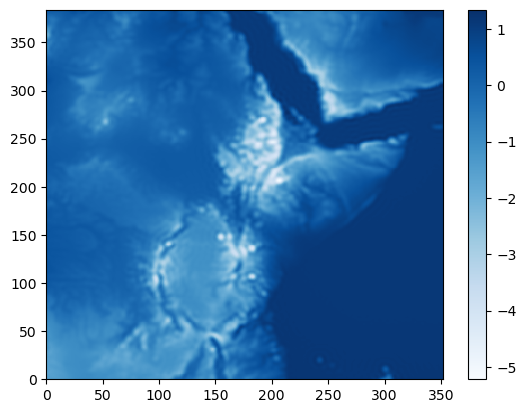

Date in cGAN  : 2020-05-03 00:00:00
Date in netCDF: 2020-05-03 00:00:00
Dates are the same


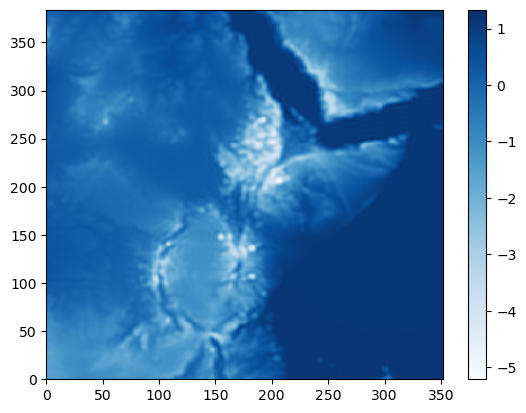

Max difference = 0.050420303933499167


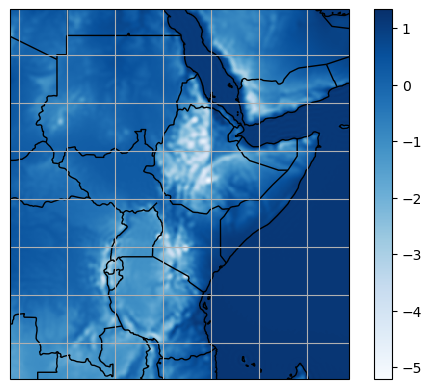

In [14]:
##################
# Each IFS field #
##################

for i in range(len(all_fcst_fields)):
    field_name = all_fcst_fields[i]
    print(field_name)
    
    # Show the field used in cGAN
    plt.pcolormesh(np.squeeze(sample[0]['lo_res_inputs'][0,:,:,i*2]), cmap='Blues')
    plt.colorbar()
    plt.show()

    # Get the date of the current sample
    year = int(dates_batch[0][0:4])
    month = int(dates_batch[0][4:6])
    day = int(dates_batch[0][6:8])
    dt = datetime(year,month,day) - datetime(year,1,1)

    
    # Load the same field from the original netCDF files
    nc_file = nc.Dataset(f"E:/CGAN/IFS_training/{year}/{field_name}.nc")
    lat = np.array(nc_file['latitude'][:])
    lon = np.array(nc_file['longitude'][:])
    time_nc = np.array(nc_file["time"][dt.days])
    plot_field = np.array(nc_file[f"{field_name}_mean"][dt.days,5:10,:,:])
    nc_file.close()

    # Check that I have the correct date
    cGAN_date = datetime(year,month,day)
    netCDF_date = datetime(1900,1,1)+timedelta(hours=int(time_nc))
    print(f"Date in cGAN  : {cGAN_date}");
    print(f"Date in netCDF: {netCDF_date}");
    if (cGAN_date != netCDF_date):
        print("ERROR: Dates are not the same")
    else:
        print("Dates are the same")
    
    if field_name in ['tp', 'cp', 'pr', 'prl', 'prc']:
        plot_field = np.mean(plot_field[:-1,:,:], axis=0)
        plot_field[plot_field < 0] = 0.
        plot_field = 1000*plot_field/6
        plot_field = np.log10(1+plot_field)
    elif field_name in ['mcc']:
        # Field is not normalised
        # Average using the trapezium rule
        plot_field = (plot_field[0,:,:]/2 + np.sum(plot_field[1:4,:,:], axis=0) + plot_field[4,:,:]/2) / 4
    elif field_name in ['ssr']:
        plot_field = np.mean(plot_field[:-1,:,:], axis=0)
        plot_field[plot_field < 0] = 0.
        plot_field /= 3600 * 6
        plot_field /= fcst_norm[field_name]["max"]
    elif field_name in ['mcc', 'tciw', 'tclw', 'tcrw', 'tcw', 'tcwv']:
        # Average using the trapezium rule
        plot_field = (plot_field[0,:,:]/2 + np.sum(plot_field[1:4,:,:], axis=0) + plot_field[4,:,:]/2) / 4
        plot_field /= fcst_norm[field_name]["max"]
    elif field_name in ['u700', 'v700']:
        # Average using the trapezium rule
        plot_field = (plot_field[0,:,:]/2 + np.sum(plot_field[1:4,:,:], axis=0) + plot_field[4,:,:]/2) / 4
        plot_field /= max(-fcst_norm[field_name]["min"], fcst_norm[field_name]["max"])
    elif field_name in ['sp', 't2m']:
        # Average using the trapezium rule
        plot_field = (plot_field[0,:,:]/2 + np.sum(plot_field[1:4,:,:], axis=0) + plot_field[4,:,:]/2) / 4
        plot_field = ( (plot_field-fcst_norm[field_name]['mean'])/fcst_norm[field_name]['std'] )
    else:
        print(f"ERROR: Unknown field name {plot_field}")

    plt.pcolormesh(plot_field, cmap='Blues')
    plt.colorbar()
    plt.show()
    
    print(f"Max difference = {np.max(np.abs(plot_field - sample[0]['lo_res_inputs'][0,:,:,i*2]))}")
    
    fig = plt.figure()
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.gridlines()
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=1)
    c = plt.pcolormesh(lon, lat, plot_field, transform=ccrs.PlateCarree(), cmap='Blues')
    cb = plt.colorbar(c)
    plt.show()